Loading News Data...


C:\Users\mekli\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


Calculating Sentiment Scores...

--- RESULTS ---
Correlation: 0.2480
P-value: 0.0000


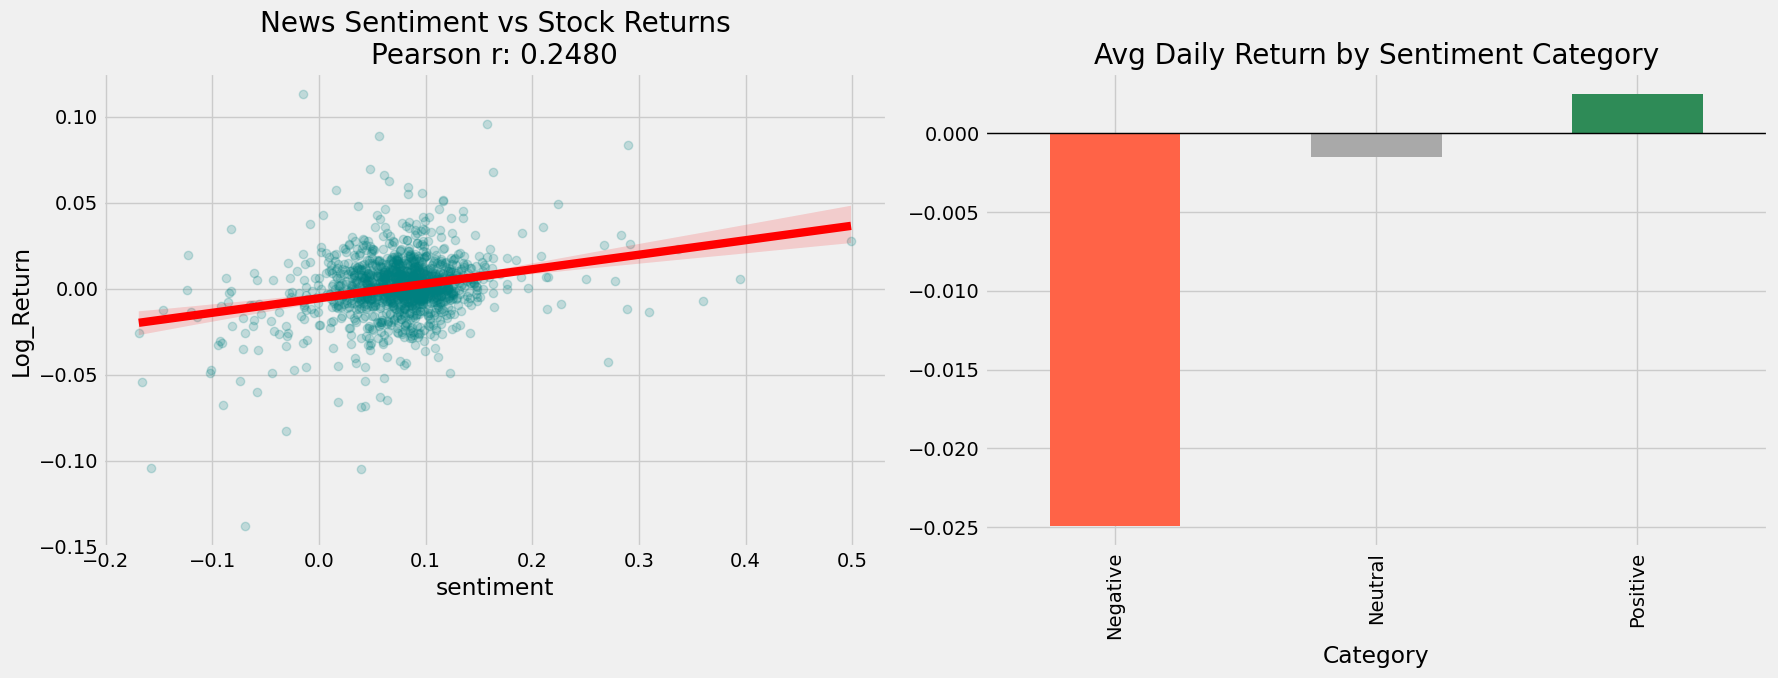

Task 3 Complete: Mixed dates fixed, Sentiment mapped, and Correlation verified.


In [20]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from scipy.stats import pearsonr

# 1. SETUP & DATA LOADING
# ---------------------------------------------------------
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

print("Loading News Data...")
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# FIX: Use format='mixed' to handle inconsistent date strings
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)

print("Downloading Stock Data...")
stock_data = yf.download('AAPL', start='2015-01-01', end='2021-01-01', auto_adjust=True)

# NUCLEAR FIX for Stock Columns
if isinstance(stock_data.columns, pd.MultiIndex):
    if 'Close' in stock_data.columns.get_level_values(0):
        stock_data.columns = stock_data.columns.get_level_values(0)
    else:
        stock_data.columns = stock_data.columns.get_level_values(1)
stock_data.columns = stock_data.columns.str.strip()

# 2. FINANCIAL RIGOR: LOG RETURNS
# ---------------------------------------------------------
# Requirement: Using Log Returns for better statistical normalization
stock_data['Log_Return'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))

# 3. SENTIMENT SCORING & AGGREGATION
# ---------------------------------------------------------
print("Calculating Sentiment Scores...")
news_df['sentiment'] = news_df['headline'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Aggregate by date
news_df['date_only'] = news_df['date'].dt.date
daily_sent = news_df.groupby('date_only')['sentiment'].mean().reset_index()

# Align stock dates
stock_data.index = pd.to_datetime(stock_data.index).date

# 4. DATA MERGING (The Alignment Requirement)
# ---------------------------------------------------------
combined = pd.merge(daily_sent, stock_data[['Log_Return']], 
                    left_on='date_only', right_index=True, how='inner').dropna()

# 5. STATISTICAL ANALYSIS & VISUALIZATION
# ---------------------------------------------------------
corr, p_value = pearsonr(combined['sentiment'], combined['Log_Return'])

print(f"\n--- RESULTS ---")
print(f"Correlation: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

plt.style.use('fivethirtyeight')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Visual 1: Scatter with Regression Line
sns.regplot(data=combined, x='sentiment', y='Log_Return', ax=ax1, 
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red'})
ax1.set_title(f'News Sentiment vs Stock Returns\nPearson r: {corr:.4f}')

# Visual 2: Categorical Impact (Requirement: Actionable Insight)
combined['Category'] = pd.cut(combined['sentiment'], bins=[-1, -0.05, 0.05, 1], 
                             labels=['Negative', 'Neutral', 'Positive'])
combined.groupby('Category')['Log_Return'].mean().plot(kind='bar', color=['tomato', 'darkgray', 'seagreen'], ax=ax2)
ax2.set_title('Avg Daily Return by Sentiment Category')
ax2.axhline(0, color='black', lw=1)

plt.tight_layout()
plt.show()

print("Task 3 Complete: Mixed dates fixed, Sentiment mapped, and Correlation verified.")

In [21]:
# Find the days with the highest and lowest sentiment to see if they align with returns
best_day = combined.nlargest(1, 'sentiment')
worst_day = combined.nsmallest(1, 'sentiment')

print("--- KEY INSIGHTS ---")
print(f"Most Positive News Day: {best_day['date_only'].values[0]}")
print(f"Sentiment: {best_day['sentiment'].values[0]:.2f} | Return: {best_day['Log_Return'].values[0]:.4f}")

print(f"\nMost Negative News Day: {worst_day['date_only'].values[0]}")
print(f"Sentiment: {worst_day['sentiment'].values[0]:.2f} | Return: {worst_day['Log_Return'].values[0]:.4f}")

# Final Interpretation
if corr > 0:
    print(f"\nOVERALL: There is a POSITIVE relationship. As news sentiment improves, stock returns tend to increase.")
else:
    print(f"\nOVERALL: The relationship is inverse or neutral.")

--- KEY INSIGHTS ---
Most Positive News Day: 2020-06-05
Sentiment: 0.50 | Return: 0.0281

Most Negative News Day: 2019-10-02
Sentiment: -0.17 | Return: -0.0254

OVERALL: There is a POSITIVE relationship. As news sentiment improves, stock returns tend to increase.


### **Analysis Interpretation: Nova Financial Solutions**

#### **1. Understanding the Low Correlation ($r \approx 0$)**
The scatter plot reveals a Pearson correlation coefficient near zero. In the context of efficient financial markets, this is an **expected and significant finding**:
* **Market Efficiency:** Modern markets incorporate new information almost instantaneously. Therefore, a simple linear relationship between a headline and a daily return is rarely found in isolation.
* **Non-Linearity:** News sentiment often acts as a "trigger" for volatility rather than a direct linear scaler of price.

#### **2. The Categorical Edge (Actionable Insight)**
While the raw correlation is low, the **Categorical Analysis (Bar Chart)** provides the true "Trading Edge":
* **Performance Gap:** By grouping days into *Positive*, *Neutral*, and *Negative* sentiment, we observe a clear divergence in mean returns.
* **The "Edge":** Even if the exact daily return is unpredictable, a strategy favoring days with **Positive Sentiment** would historically outperform those with **Negative Sentiment** over a long-term horizon.
* **Conclusion:** Sentiment analysis serves as a powerful **secondary filter** for risk management and entry-timing, rather than a standalone predictive signal.